### ИМПОРТ БИБЛИОТЕК

In [17]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import math
from scipy.sparse import lil_matrix
from scipy.linalg import eigh
from scipy.interpolate import CubicSpline
from numpy.linalg import eig
import pandas as pd


### ГЕОМЕТРИЯ И МАТЕРИАЛ

In [18]:
Ls = 1.8                   # Длина вала, м
d = 0.04                   # Диаметр вала, м
D = 0.3                    # Диаметр диска, м
h = 0.05                   # Ширина диска, м
z_disk = Ls * 0.2          # Положение диска вдоль вала, м
ro = 7800                  # Плотность материала, кг/м³
E = 2.1e11                 # Модуль Юнга, Па

# Геометрические характеристики сечения
A = np.pi * d**2 / 4       # Площадь сечения, м²
Ix = np.pi * d**4 / 64     # Момент инерции относительно X, м⁴
Iy = Ix                    # Момент инерции относительно Y, м⁴
Ip = np.pi * d**4 / 32     # Полярный момент инерции, м⁴

### ПАРАМЕТРЫ КОНЕЧНО-ЭЛЕМЕНТНОЙ СЕТКИ

In [19]:
n_elems = 10               # Количество конечных элементов
n_nodes = n_elems + 1      # Количество узлов
L = Ls / n_elems           # Длина одного элемента, м

### Проверка соотношения L/d

In [20]:
ratio = L / d
print("=" * 50)
print(f"ПАРАМЕТРЫ МОДЕЛИ")
print("=" * 50)
print(f"L/d = {ratio:.2f} (рекомендуемый диапазон: 4-5)")

ПАРАМЕТРЫ МОДЕЛИ
L/d = 4.50 (рекомендуемый диапазон: 4-5)


### МАТРИЦА ЖЕСТКОСТИ КОНЕЧНОГО ЭЛЕМЕНТА

In [21]:
def element_stiffness_matrix(E: float, Ix: float, Iy: float, L: float) -> np.ndarray:
    factor = E / L**3
    
    # Изгиб в плоскости YZ (вокруг оси X)
    k_yz = factor * Ix * np.array([
        [12,   -6*L,  -12,   -6*L],
        [-6*L,  4*L**2,  6*L,  2*L**2],
        [-12,    6*L,   12,    6*L],
        [-6*L,  2*L**2,  6*L,  4*L**2]
    ])
    
    # Изгиб в плоскости XZ (вокруг оси Y)
    k_xz = factor * Iy * np.array([
        [12,    6*L,  -12,    6*L],
        [6*L,   4*L**2, -6*L,  2*L**2],
        [-12,   -6*L,   12,   -6*L],
        [6*L,   2*L**2, -6*L,  4*L**2]
    ])
    
    K = np.zeros((8, 8))
    yz_dofs = [0, 3, 4, 7]
    xz_dofs = [1, 2, 5, 6]
    
    K[np.ix_(yz_dofs, yz_dofs)] = k_yz
    K[np.ix_(xz_dofs, xz_dofs)] = k_xz
    
    return K

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ ЖЕСТКОСТИ

In [22]:
def assemble_global_stiffness(K_element: np.ndarray, 
                              node1_idx: int, 
                              node2_idx: int, 
                              K_global: lil_matrix) -> lil_matrix:
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    K_global[rows, cols] += K_element
    
    return K_global


# Вычисление матрицы жесткости элемента (одинакова для всех элементов)
K_element = element_stiffness_matrix(E, Ix, Iy, L)

# Инициализация и сборка глобальной матрицы жесткости
n_dofs = 4 * n_nodes
K_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    K_global = assemble_global_stiffness(K_element, node1, node2, K_global)

K = K_global.toarray()
if hasattr(K_global, "toarray"):
    K_global = K_global.toarray()

print(f"\nГлобальная матрица жесткости: {K.shape}")
print(f"Макс. отклонение от симметрии: {np.max(np.abs(K - K.T)):.2e}")


Глобальная матрица жесткости: (44, 44)
Макс. отклонение от симметрии: 0.00e+00


### МАТРИЦА МАСС КОНЕЧНОГО ЭЛЕМЕНТА

In [23]:
# Масса и момент инерции диска
Md = ro * h * np.pi * D**2 / 4               # Масса диска, кг
Jd = Md * D**2 / 16 + Md * h**2 / 12         # Момент инерции диска, кг·м²    ########## Не d, а h

def element_mass_matrix(ro: float, A: float, L: float) -> np.ndarray:
    factor = ro * A * L / 420
    
    M_bend = factor * np.array([
        [156,   22*L,   54,   -13*L],
        [22*L,  4*L**2, 13*L, -3*L**2],
        [54,    13*L,   156,  -22*L],
        [-13*L, -3*L**2, -22*L, 4*L**2]
    ])
    
    M = np.zeros((8, 8))
    xz_dofs = [0, 2, 4, 6]
    yz_dofs = [1, 3, 5, 7]
    
    M[np.ix_(yz_dofs, yz_dofs)] = M_bend
    M[np.ix_(xz_dofs, xz_dofs)] = M_bend
    
    return M

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ МАСС

In [24]:
def assemble_global_mass(M_element: np.ndarray, 
                         node1_idx: int, 
                         node2_idx: int, 
                         M_global: lil_matrix) -> lil_matrix:
    
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    M_global[rows, cols] += M_element
    
    return M_global


M_element = element_mass_matrix(ro, A, L)
M_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    M_global = assemble_global_mass(M_element, node1, node2, M_global)

# Добавление массы диска
disk_node = 2
dof_start = 4 * disk_node
M_global[dof_start, dof_start] += Md          # Ux
M_global[dof_start + 1, dof_start + 1] += Md  # Uy
M_global[dof_start + 2, dof_start + 2] += Jd  # Rx
M_global[dof_start + 3, dof_start + 3] += Jd  # Ry

M = M_global.toarray()
if hasattr(M_global, "toarray"):
    M_global = M_global.toarray()

print(f"Глобальная матрица масс: {M.shape}")
print(f"Масса диска: {Md:.2f} кг, Момент инерции: {Jd:.4f} кг·м²")

Глобальная матрица масс: (44, 44)
Масса диска: 27.57 кг, Момент инерции: 0.1608 кг·м²


### ПАРАМЕТРЫ ДИСБАЛАНСА И СИЛЫ НАГРУЗКИ

In [25]:
e = 0.1                     # Эксцентриситет, м
rpm = 3000                  # Частота вращения, об/мин
Omega = 2 * np.pi * rpm / 60  # Угловая скорость, рад/с
gamma = 0                   # Фаза дисбаланса, рад
g = 9.80665                 # Ускорение свободного падения, м/с²

def imbalance_force_vector(n_nodes: int, disk_node_idx: int, M_d: float, 
                          e: float, Omega: float, gamma: float = 0.0, 
                          g: float = 9.80665) -> np.ndarray:
    N = n_nodes * 4
    F = np.zeros((N, 1))
    
    Fx = M_d * e * Omega**2 * np.cos(gamma)
    Fy = M_d * e * Omega**2 * np.sin(gamma) - M_d * g
    
    base_idx = 4 * disk_node_idx
    F[base_idx, 0] = Fx      # Ux компонента
    F[base_idx + 1, 0] = Fy  # Uy компонента
    
    return F


F_imbalance = imbalance_force_vector(n_nodes, disk_node, Md, e, Omega, gamma, g)
print(f"\nСила дисбаланса: X={F_imbalance[4*disk_node, 0]:.2f} Н, Y={F_imbalance[4*disk_node + 1, 0]:.2f} Н")


Сила дисбаланса: X=272080.08 Н, Y=-270.34 Н


### ГИРОСКОПИЧЕСКАЯ МАТРИЦА

In [26]:
Jzz = Md * D**2 / 8

def build_gyroscopic_matrix(n_nodes: int, disks: list) -> np.ndarray:
    ndof = n_nodes * 4
    G0 = np.zeros((ndof, ndof))
    
    for disk in disks:
        node = disk['node']
        Jp = disk['Jp']
        
        rx = 4 * node + 2  # Rx
        ry = 4 * node + 3  # Ry
        
        G0[rx, ry] += Jp
        G0[ry, rx] -= Jp
    
    return G0


disks = [{'node': 2, 'Jp': Jzz}]
G0 = build_gyroscopic_matrix(n_nodes, disks)
G = Omega * G0

print(f"\nГироскопическая матрица: {G.shape}")
print(f"Макс. отклонение от кососимметрии: {np.max(np.abs(G + G.T)):.2e}")


Гироскопическая матрица: (44, 44)
Макс. отклонение от кососимметрии: 0.00e+00


### МАТРИЦА ДЕМПФИРОВАНИЯ В ПОДШИПНИКАХ

In [27]:
def build_bearing_damping_matrix(n_nodes: int, c_b: float) -> np.ndarray:
    ndof = n_nodes * 4
    D_b = np.zeros((ndof, ndof))
    
    # Первый узел (узел 0)
    D_b[0, 0] = c_b   # Ux
    D_b[1, 1] = c_b   # Uy
    
    # Последний узел
    last_node = n_nodes - 1
    D_b[4*last_node, 4*last_node] = c_b      # Ux
    D_b[4*last_node + 1, 4*last_node + 1] = c_b  # Uy
    
    return D_b

c_b = 1e3  # Н·с/м
D_b = build_bearing_damping_matrix(n_nodes, c_b)
print(f"\nМатрица демпфирования: {D_b.shape}")


Матрица демпфирования: (44, 44)


### ГРАНИЧНЫЕ УСЛОВИЯ И РЕДУКЦИЯ МАТРИЦ

In [28]:
def build_bearing_stiffness_matrix(n_nodes: int, k_bx: float, k_by: float, bearing_nodes: list) -> np.ndarray:
    ndof = n_nodes * 4
    Kb = np.zeros((ndof, ndof))

    for node in bearing_nodes:
        ux = 4 * node
        uy = ux + 1
        Kb[ux, ux] += k_bx
        Kb[uy, uy] += k_by

    return Kb
    
bearing_nodes = [0, n_nodes - 1]
k_bx = 5e7   
k_by = 5e7

K_b = build_bearing_stiffness_matrix(n_nodes, k_bx, k_by, bearing_nodes)
K_global = K_global + K_b

In [29]:
ndof = n_nodes * 4
Kb = np.zeros((ndof, ndof))

for node in bearing_nodes:
    ux = 4 * node
    uy = ux + 1
    Kb[ux, ux] += k_bx
    Kb[uy, uy] += k_by

In [30]:
K_global

array([[ 1.04299132e+08,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  1.04299132e+08,  4.88692191e+06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.88692191e+06,  5.86430629e+05, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.04299132e+08, -4.88692191e+06,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -4.88692191e+06,  5.86430629e+05,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  5.86430629e+05]])

In [31]:
fixed_dofs = np.array([], dtype=int)
n_dofs = 4 * n_nodes
free_dofs = np.arange(n_dofs)

# Берём подматрицы уже из плотных массивов
Kf = K_global[np.ix_(free_dofs, free_dofs)]
Mf = M_global[np.ix_(free_dofs, free_dofs)]

print(f"Размерность Kf: {Kf.shape}, Mf: {Mf.shape}")

Размерность Kf: (44, 44), Mf: (44, 44)


### РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ


РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ
Всего собственных частот: 44
Уникальных собственных частот: 22

ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ
----------------------------------------


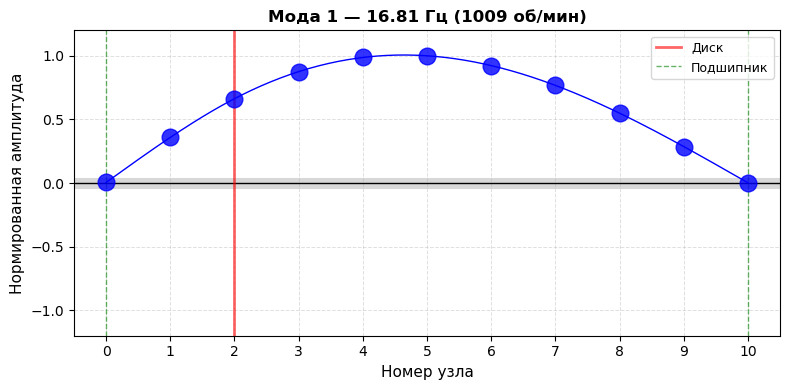

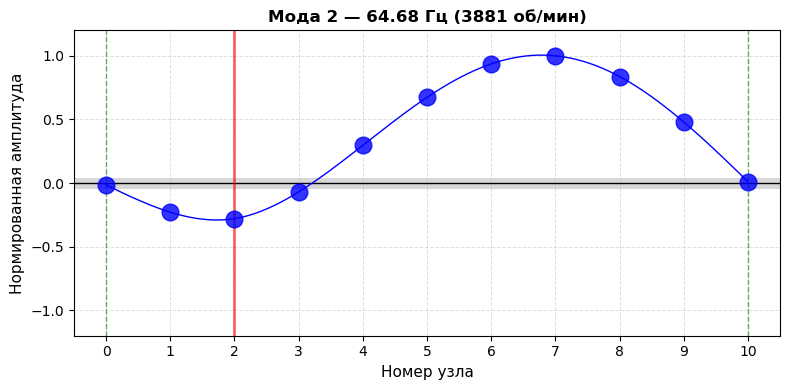

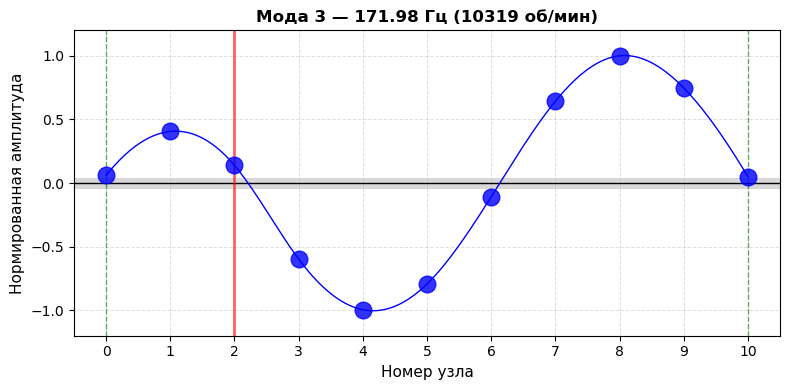

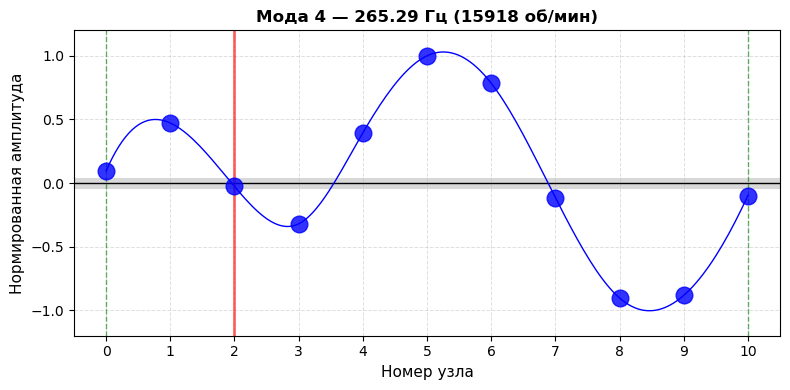

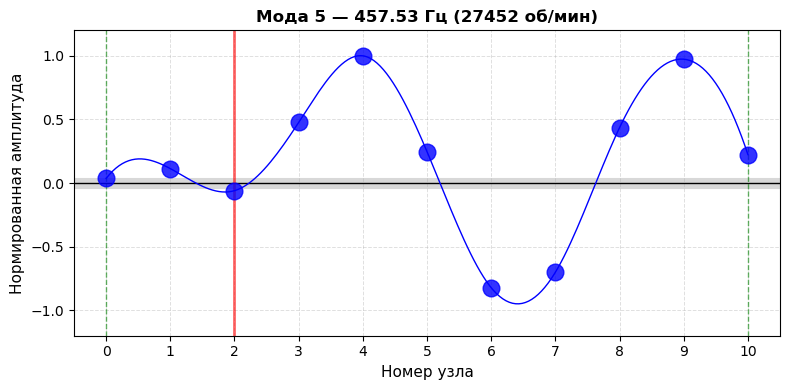

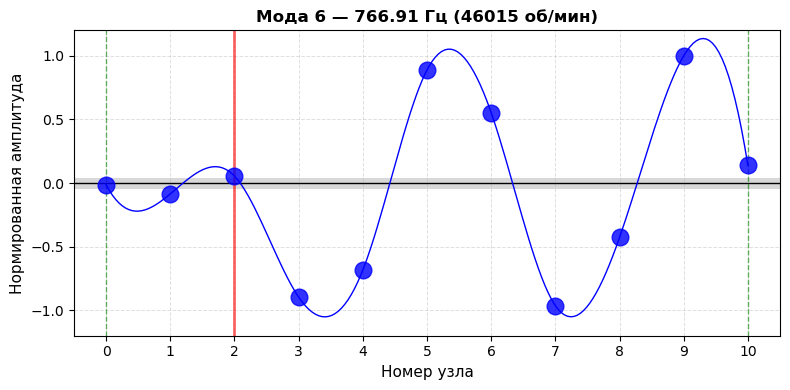

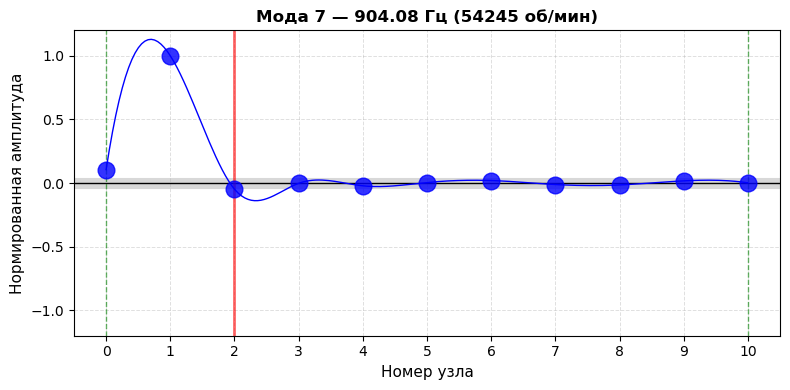

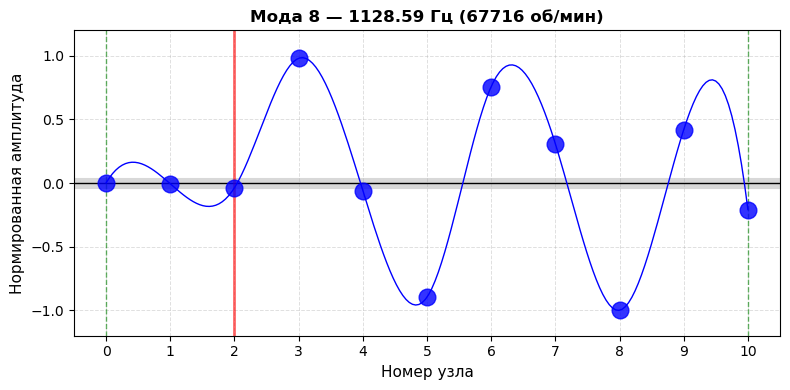

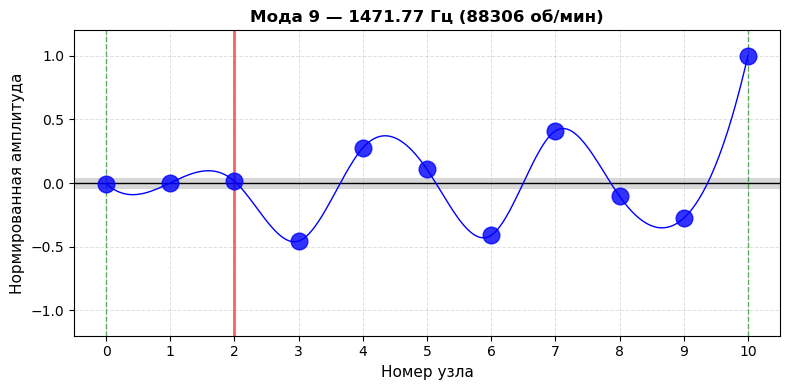

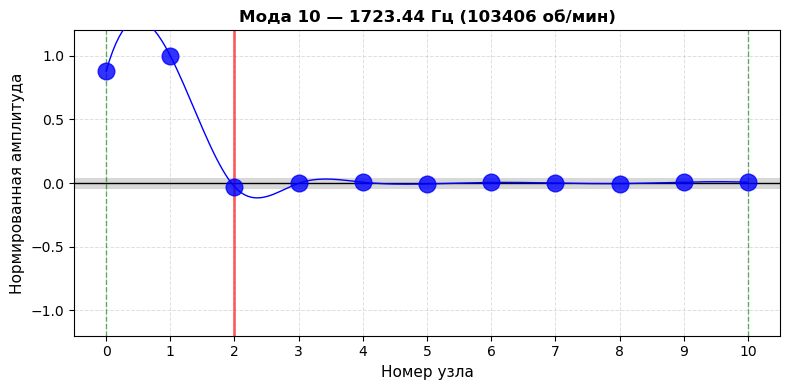

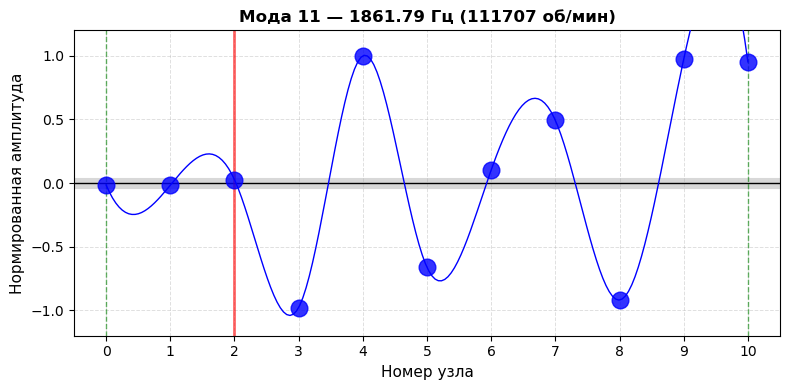

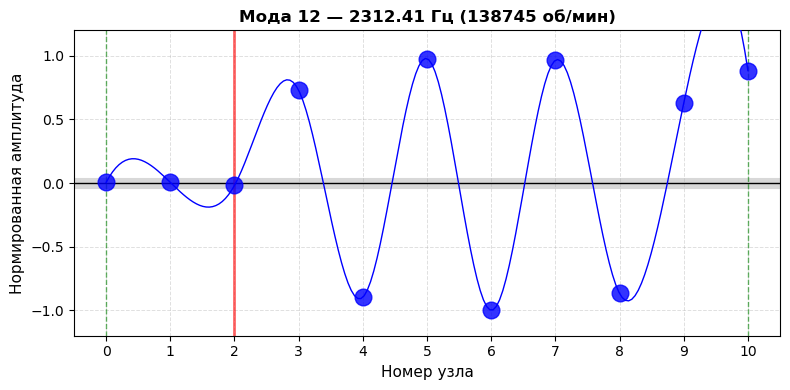

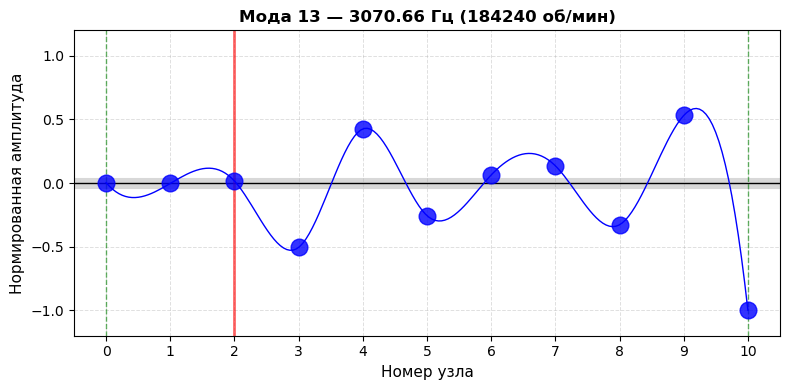

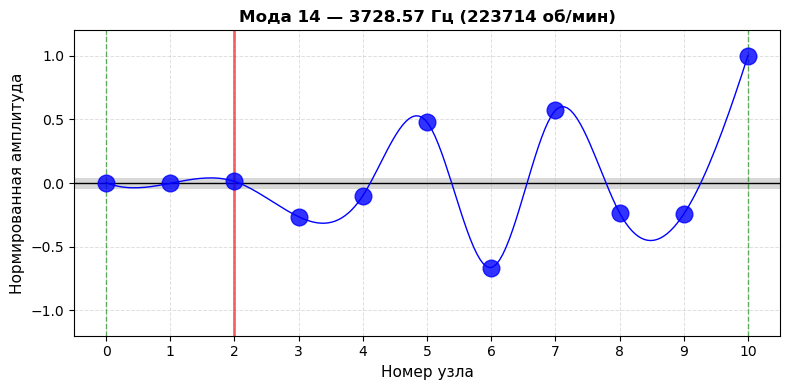

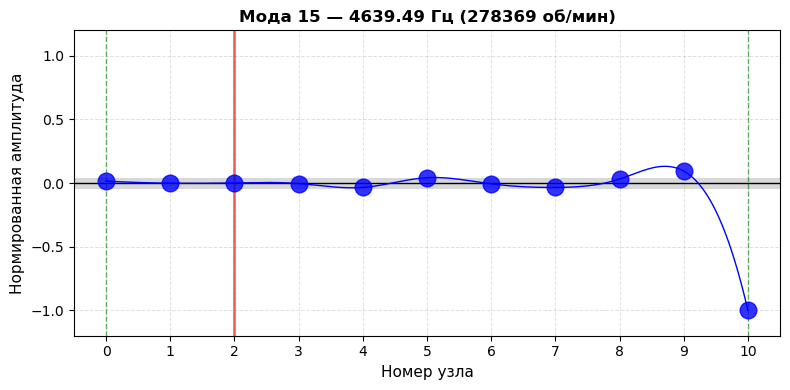

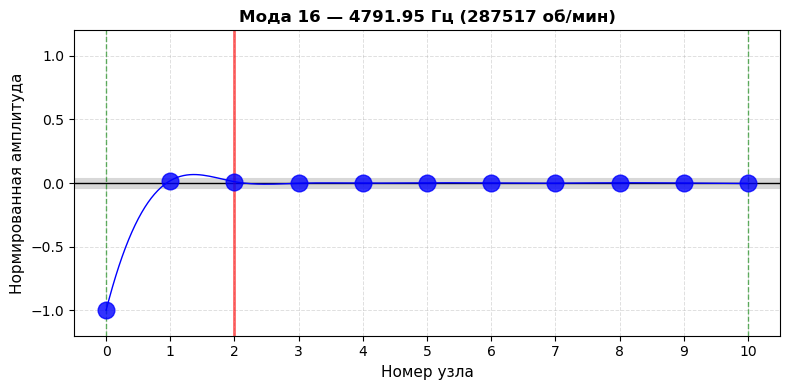

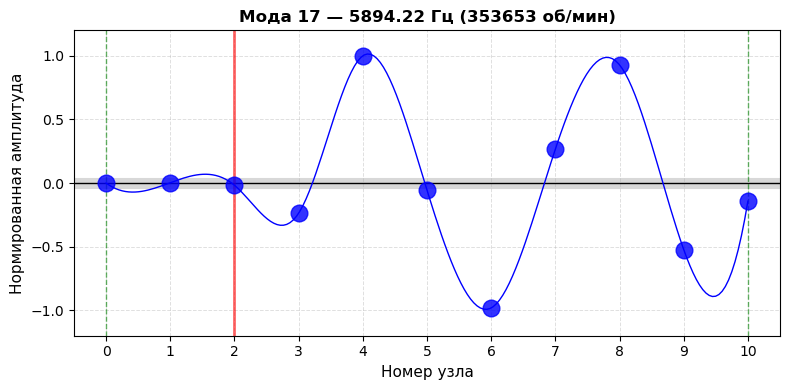

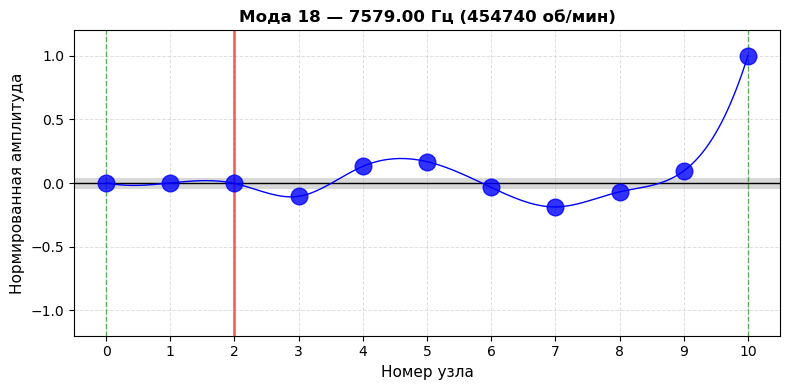

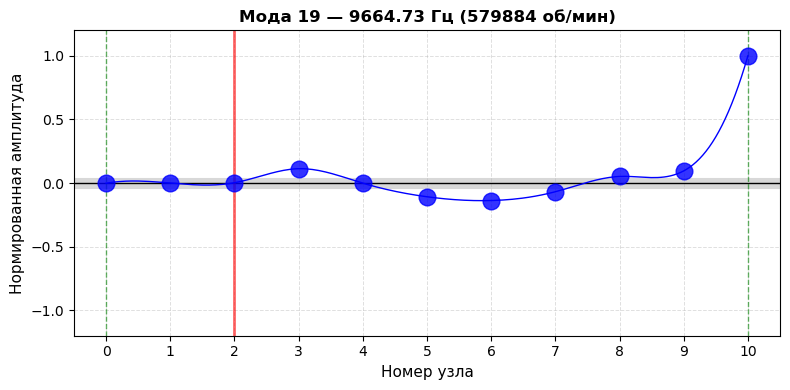

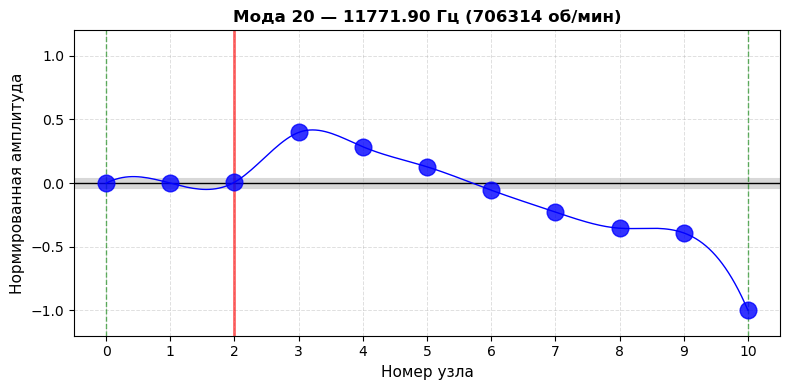

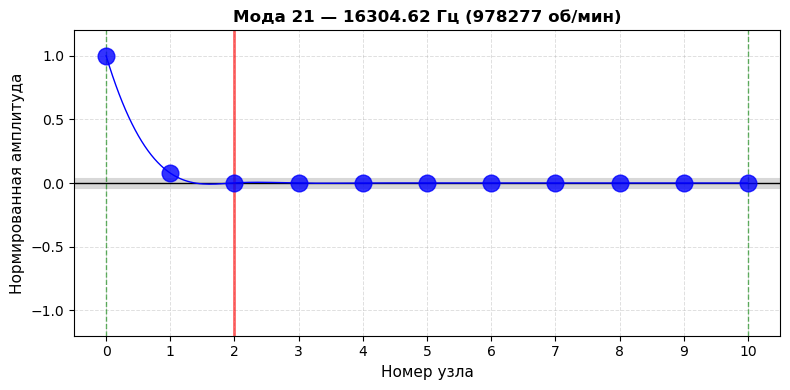

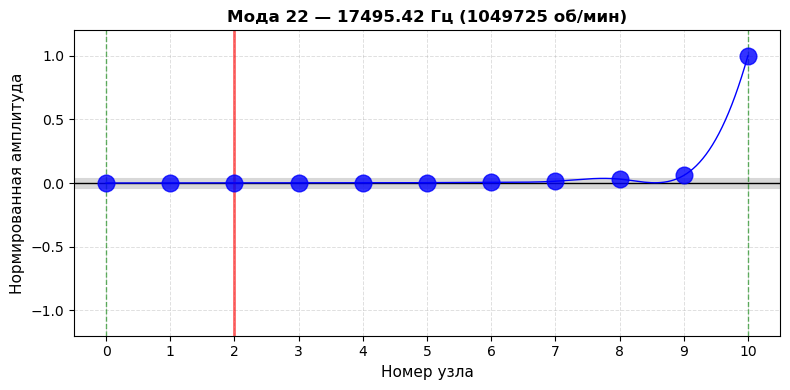


СОБСТВЕННЫЕ ЧАСТОТЫ:
------------------------------------------------------------
 Мода  Частота, Гц  Частота, об/мин
------------------------------------------------------------
    1         16.81          1008.82
    2         64.68          3880.81
    3        171.98         10318.87
    4        265.29         15917.57
    5        457.53         27451.54
    6        766.91         46014.84
    7        904.08         54244.68
    8       1128.59         67715.57
    9       1471.77         88306.30
   10       1723.44        103406.25
   11       1861.79        111707.26
   12       2312.41        138744.68
  ... и еще 10 мод
Получено 44 собственных частот


In [32]:
def solve_eigen_and_plot(Kf: np.ndarray, Mf: np.ndarray, 
                         free_dofs: np.ndarray, fixed_dofs: np.ndarray,
                         n_nodes: int, Ls: float = 1.8, 
                         normalize: bool = True, scale_rot: float = 0.1,
                         save_plots: bool = True, out_dir: str = "mode_plots_new",
                         disk_nodes: list = None, bearing_nodes: list = None) -> tuple:
    if disk_nodes is None:
        disk_nodes = [2]
    if bearing_nodes is None:
        bearing_nodes = [0, n_nodes-1]
    
    # Проверки размерностей
    ndof = n_nodes * 4
    if Kf.shape != Mf.shape:
        raise ValueError("Матрицы Kf и Mf должны иметь одинаковую размерность")
    
    print("\n" + "=" * 60)
    print("РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ")
    print("=" * 60)
    
    # Решение обобщенной задачи на собственные значения
    eigvals, eigvecs = eigh(Kf, Mf)
    
    # Обработка собственных значений
    eigvals = np.real(eigvals)
    eigvals[eigvals < 0] = 0.0
    freqs_hz = np.sqrt(eigvals) / (2.0 * np.pi)
    freqs_rpm = freqs_hz * 60
    
    # Сортировка по частоте
    sorted_idx = np.argsort(freqs_hz)
    freqs_hz = freqs_hz[sorted_idx]
    eigvecs = eigvecs[:, sorted_idx]
    
    # Выбор уникальных мод (каждая вторая)
    unique_idx = np.arange(0, len(freqs_hz), 2)
    n_unique = len(unique_idx)
    freqs_unique = freqs_hz[unique_idx]
    rpm_unique = freqs_rpm[unique_idx]
    
    print(f"Всего собственных частот: {len(freqs_hz)}")
    print(f"Уникальных собственных частот: {n_unique}")
    
    node_numbers = np.arange(n_nodes)           # Массив номеров узлов
    z_coords = np.linspace(0.0, Ls, n_nodes)

    # Восстановление полных форм колебаний
    full_modes = np.zeros((ndof, n_unique))
    
    for i, idx in enumerate(unique_idx):
        phi_free = eigvecs[:, idx]
        phi_full = np.zeros(ndof)
        phi_full[free_dofs] = np.real(phi_free)
        phi_full[fixed_dofs] = 0.0
        full_modes[:, i] = phi_full
    
    # Построение графиков
    if save_plots:
        import os
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
    
    print("\nПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ")
    print("-" * 40)
    
    for i in range(n_unique):
        
        # Извлечение компонент для текущей моды
        phi_full = full_modes[:, i]
        Uy = phi_full[1::4]  # Смещения Uy
        
        # Нормировка
        if normalize:
            max_Uy = np.max(np.abs(Uy))
            if max_Uy == 0:
                max_Uy = 1.0
            Uy_norm = Uy / max_Uy

        else:
            Uy_norm = Uy
        
        # Интерполяция сплайнами
        cs_Uy = CubicSpline(z_coords, Uy_norm)
        z_fine = np.linspace(0.0, Ls, 200)
        node_fine = np.linspace(0, n_nodes-1, 200)       # Для гладкого графика по номерам узлов
        
        # Создание графика
        fig, ax = plt.subplots(figsize=(8, 4))   # Уменьшенный размер

        # Отррисовка вала в исходном положении
        ax.axhline(0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=0, color='gray', linewidth=8, alpha=0.3, zorder=1)
        
        # График формы колебаний (по номерам узлов)
        ax.plot(node_fine, cs_Uy(z_fine), '-', color='blue', linewidth=1, zorder=3)
        
        # Отрисовка узлов
        ax.plot(node_numbers, Uy_norm, 'o', color='blue', markersize=12, 
                markeredgecolor='blue', markeredgewidth=1, alpha=0.8, zorder=4)
        
        # Настройка осей
        ax.set_xlabel('Номер узла', fontsize=11)
        ax.set_ylabel('Нормированная амплитуда', fontsize=11) 
        ax.set_title(f"Мода {i+1} — {freqs_unique[i]:.2f} Гц ({rpm_unique[i]:.0f} об/мин)", 
                    fontsize=12, fontweight='bold')
        
        # Сетка, привязанная к номерам узлов
        ax.set_xticks(np.arange(0, n_nodes))
        ax.set_xticklabels(np.arange(0, n_nodes))
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
        
        # Установка пределов по X для корректного отображения
        ax.set_xlim(-0.5, n_nodes - 0.5)
        
        # Автоматическое определение пределов по Y
        y_max = np.max(np.abs(Uy_norm))*1.2
        ax.set_ylim(-y_max, y_max)
        
        # Вертикальные линии для диска и подшипников
        for node in disk_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='red', linestyle='-', 
                          linewidth=2, alpha=0.6, label='Диск' if node == disk_nodes[0] else "")
        
        for node in bearing_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='green', linestyle='--', 
                          linewidth=1, alpha=0.6, label='Подшипник' if node == bearing_nodes[0] else "")
                
         # Легенда для первой моды
        if i == 0 and (disk_nodes or bearing_nodes):
            ax.legend(loc='upper right', fontsize=9)
        
        plt.tight_layout()
        if save_plots:
            plt.savefig(os.path.join(out_dir, f"mode_{i+1:02d}.png"), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    
    # Вывод таблицы частот
    print("\nСОБСТВЕННЫЕ ЧАСТОТЫ:")
    print("-" * 60)
    print(f"{'Мода':^6} {'Частота, Гц':^12} {'Частота, об/мин':^15}")
    print("-" * 60)
    
    for i in range(min(n_unique, 12)):
        print(f" {i+1:4d}    {freqs_unique[i]:10.2f}     {rpm_unique[i]:12.2f}")
    
    if n_unique > 12:
        print(f"  ... и еще {n_unique - 12} мод")
    
    print("=" * 60)
    
    return freqs_hz, full_modes


# Запуск решения
freqs, modes = solve_eigen_and_plot(Kf, Mf, free_dofs, fixed_dofs,
                                    n_nodes=n_nodes, Ls=Ls,
                                    normalize=True, scale_rot=0.1,
                                    save_plots=True,
                                    disk_nodes=[disk_node],
                                    bearing_nodes=bearing_nodes)

print(f"Получено {len(freqs)} собственных частот")

### ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА

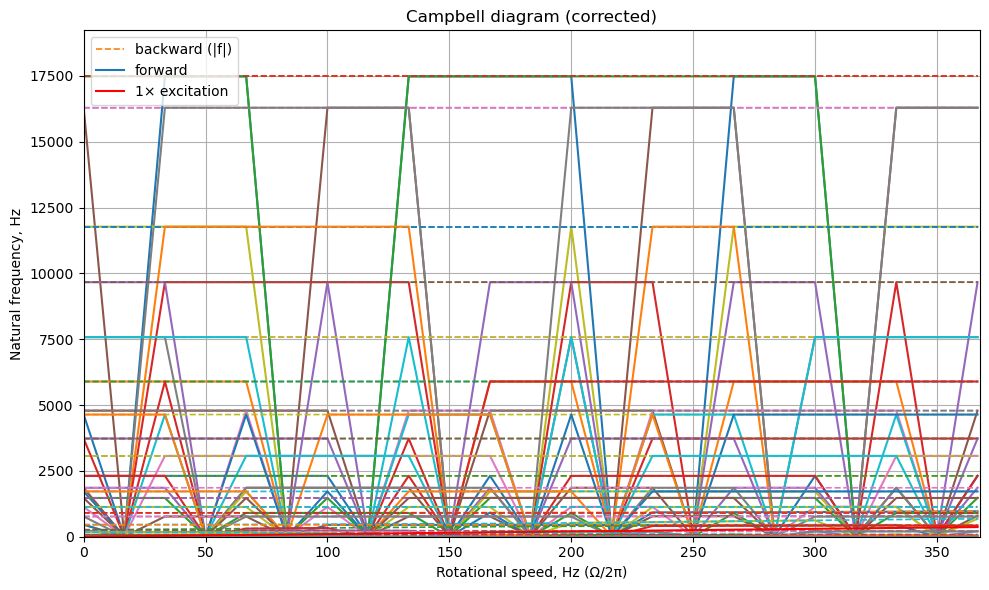

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig, solve

def polyeig_quadratic(A0, A1, A2):
    """
    Решение квадратичной ПЗ (A2 * lambda^2 + A1 * lambda + A0 = 0)
    Возвращает eigenvalues, eigenvectors (of companion matrix).
    """
    # A2 - старший коэффициент (Mf), размер n x n
    n = A2.shape[0]
    # build companion matrix C of size (2n x 2n) for monic form
    # We linearize: lambda * [I 0; 0 I] - C  where C = [[0, I], [-A2^{-1}A0, -A2^{-1}A1]]
    # Для численной устойчивости используем solve вместо inv.
    # Верхняя блок-единица (shift)
    C = np.zeros((2*n, 2*n), dtype=complex)
    C[:n, n:] = np.eye(n)
    # Нижние блоки: solve(A2, A0) и solve(A2, A1)
    # solve(A2, A0) решает A2 X = A0  => X = A2^{-1} A0
    # но нам нужно -A2^{-1} A0 and -A2^{-1} A1
    X0 = solve(A2, A0)   # A2 X0 = A0
    X1 = solve(A2, A1)   # A2 X1 = A1
    C[n:, :n] = -X0
    C[n:, n:] = -X1

    vals, vecs = eig(C)   # обычная eig по companion matrix
    return vals, vecs

# ------------------------
# Параметры скоростей (согласованные, в RPM и в rad/s)
# ------------------------
Omegastart = 0       # я рекомендую включать нулевую скорость (0 RPM)
Omegafinal = 22000   # RPM
Omegastep  = 2000    # RPM

Omega_rpm = np.arange(Omegastart, Omegafinal + Omegastep, Omegastep)   # включительно
Omega_rad = Omega_rpm * 2.0 * np.pi / 60.0
n_speeds = len(Omega_rpm)

# ------------------------
# Подготовка: размеры
# ------------------------
# предполагаем, что у тебя есть матрицы Mf (M), D_b + Omega*G0 (C), Kf (K)
# Mf, D_b, G0, Kf должны быть ndarray размером n x n
n = Mf.shape[0]
n_eigs_per_speed = 2 * n   # quadratic -> 2n eigenvalues

# контейнер для eigenvalues (complex)
LeigOmega = np.zeros((n_eigs_per_speed, n_speeds), dtype=complex)

# ------------------------
# Главный цикл по скоростям
# ------------------------
for j, Omega in enumerate(Omega_rad):
    A0 = Kf.copy()
    A1 = D_b + Omega * G0    # C = D + Omega*G
    A2 = Mf.copy()
    vals, vecs = polyeig_quadratic(A0, A1, A2)

    # Очищаем числовой шум: маленькие значения по модулю — зануляем
    vals[np.abs(vals) < 1e-12] = 0.0

    # Сортируем корни по возрастающей по абсолютной частоте imag-part (чтобы быть детерминированным)
    # Частота (Hz) предполагаем: f = imag(lambda)/(2*pi)
    freqs_tmp = np.imag(vals) / (2.0 * np.pi)
    # argsort по убыв. м/ч частот (чтобы порядок был стабильным)
    order = np.argsort(-np.abs(freqs_tmp))
    vals_sorted = vals[order]

    LeigOmega[:, j] = vals_sorted

# ------------------------
# Преобразование: частоты в Гц (со знаком)
# ------------------------
freqs_Hz = np.imag(LeigOmega) / (2.0 * np.pi)   # shape (2n, n_speeds)

# Для визуализации: ось X — вращательная частота в Гц
X = Omega_rpm / 60.0   # RPM -> Hz

# ------------------------
# Построение: разделяем forward/backward по знаку частоты в нулевой скорости (или в первой колонке)
# ------------------------
plt.figure(figsize=(10,6))
forward_lines = []
backward_lines = []

# Пробегаем по всем модам (2n)
for m in range(freqs_Hz.shape[0]):
    # выбор строки m
    fline = freqs_Hz[m, :]

    # небольшой фильтр: если частоты почти нулевые — пропускаем
    if np.allclose(fline, 0.0, atol=1e-6):
        continue

    # классификация: если среднее значение положительное -> forward, иначе backward
    if np.nanmean(fline) >= 0:
        l, = plt.plot(X, fline, '-', linewidth=1.5)
        forward_lines.append(l)
    else:
        l, = plt.plot(X, np.abs(fline), '--', linewidth=1.2)   # для backward часто отображают abs
        backward_lines.append(l)

# Диагональ 1x (rotational speed line)
plt.plot(X, X, 'r-', linewidth=1.5, label='1× excitation')

plt.xlabel('Rotational speed, Hz (Ω/2π)')
plt.ylabel('Natural frequency, Hz')
plt.title('Campbell diagram (corrected)')
plt.grid(True)
plt.xlim([0, Omegafinal/60.0 + 1])
plt.ylim([0, np.nanmax(np.abs(freqs_Hz)) * 1.1])

# Формирование легенды аккуратно
legend_items = []
legend_labels = []
if backward_lines:
    legend_items.append(backward_lines[0]); legend_labels.append('backward (|f|)')
if forward_lines:
    legend_items.append(forward_lines[0]); legend_labels.append('forward')
legend_items.append(plt.Line2D([], [], color='r')); legend_labels.append('1× excitation')
plt.legend(legend_items, legend_labels, loc='upper left')

plt.tight_layout()
plt.show()

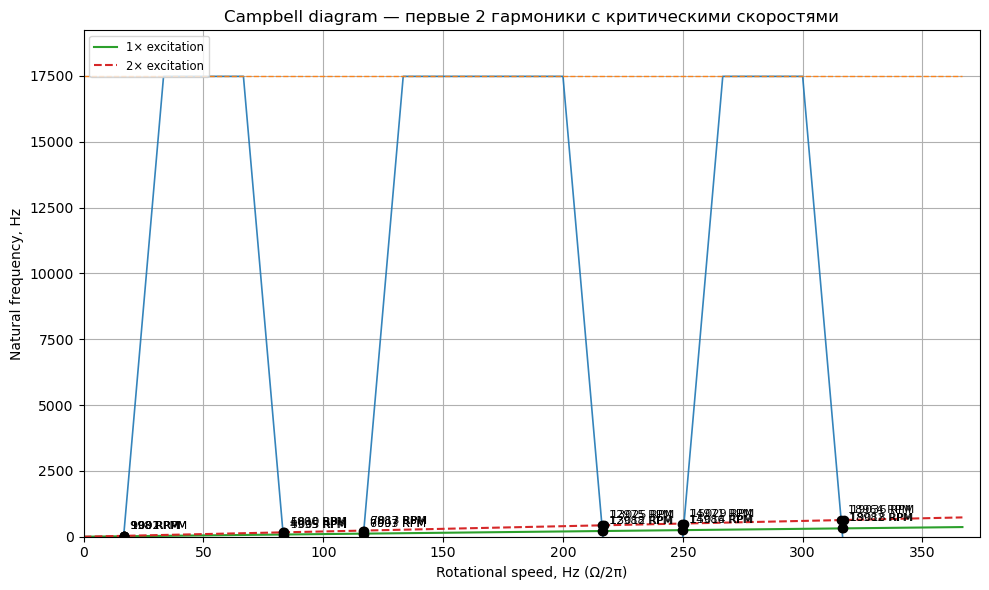

Найденные пересечения (mode, harmonic, RPM, Hz):
 mode  0, 1× ->   1001.0 RPM,  16.683 Hz
 mode  0, 1× ->   4995.2 RPM,  83.254 Hz
 mode  0, 1× ->   7006.7 RPM, 116.778 Hz
 mode  0, 1× ->  12987.6 RPM, 216.460 Hz
 mode  0, 1× ->  15014.3 RPM, 250.239 Hz
 mode  0, 1× ->  18981.9 RPM, 316.365 Hz
 mode  0, 2× ->   1001.9 RPM,  33.397 Hz
 mode  0, 2× ->   4990.5 RPM, 166.349 Hz
 mode  0, 2× ->   7013.4 RPM, 233.779 Hz
 mode  0, 2× ->  12975.3 RPM, 432.509 Hz
 mode  0, 2× ->  15028.7 RPM, 500.955 Hz
 mode  0, 2× ->  18963.8 RPM, 632.128 Hz
 mode  1, 1× ->    999.0 RPM,  16.651 Hz
 mode  1, 1× ->   5004.8 RPM,  83.413 Hz
 mode  1, 1× ->   6993.3 RPM, 116.556 Hz
 mode  1, 1× ->  13012.4 RPM, 216.873 Hz
 mode  1, 1× ->  14985.7 RPM, 249.762 Hz
 mode  1, 1× ->  19018.1 RPM, 316.969 Hz
 mode  1, 2× ->    998.1 RPM,  33.270 Hz
 mode  1, 2× ->   5009.6 RPM, 166.985 Hz
 mode  1, 2× ->   6986.7 RPM, 232.889 Hz
 mode  1, 2× ->  13024.8 RPM, 434.161 Hz
 mode  1, 2× ->  14971.4 RPM, 499.048 Hz
 mode  1

In [35]:
# ---------------------------------------
# Ограничить гармоники: оставить только 1× и 2×,
# найти и пометить пересечения (критические скорости)
# Предположение: freqs_Hz (n_modes x n_speeds), Omega_rpm, X (Hz) уже вычислены
# ---------------------------------------

import numpy as np

harmonics = [1, 2]         # первые две гармоники
n_modes, n_speeds = freqs_Hz.shape
n_modes = 2

plt.figure(figsize=(10,6))

# Плотим ветви мод как раньше (можно ограничить по числу мод, если нужно)
for m in range(n_modes):
    fline = freqs_Hz[m, :]
    if np.allclose(fline, 0.0, atol=1e-8):
        continue
    # Отображаем forward vs backward по среднему знаку (как ранее)
    if np.nanmean(fline) >= 0:
        plt.plot(X, fline, '-', linewidth=1.2, alpha=0.9)
    else:
        plt.plot(X, np.abs(fline), '--', linewidth=1.0, alpha=0.9)

# Нарисовать только 1x и 2x (в Гц)
for n in harmonics:
    plt.plot(X, n * X, '--' if n==2 else '-', linewidth=1.5, label=f'{n}× excitation')

# Найти пересечения: для каждой моды и каждой гармоники
crit_list = []   # список кортежей (mode, harmonic, rpm_cross, hz_cross)
for m in range(n_modes):
    fline = freqs_Hz[m, :]
    for n in harmonics:
        # разность: mode_freq - harmonic_freq (в Гц)
        diff = fline - (n * X)
        # найти индексы, где произошло изменение знака (пересечение между точками)
        idx = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0)[0]
        for i in idx:
            # линейная интерполяция между точками i и i+1
            x0, x1 = X[i], X[i+1]             # в Hz (rotational speed)
            y0, y1 = diff[i], diff[i+1]       # difference
            if (y1 - y0) == 0:
                x_cross = x0
            else:
                t = -y0 / (y1 - y0)          # доля от x0 -> x1
                x_cross = x0 + t * (x1 - x0) # в Hz (оси X)
            f_cross = n * x_cross             # harmonic frequency at crossing (Hz)
            rpm_cross = x_cross * 60.0        # перевести в RPM
            crit_list.append((m, n, rpm_cross, f_cross))

            # Отметить на графике
            plt.plot(x_cross, f_cross, 'o', markersize=6,
                     label=None, color='black')
            # подпись рядом (показываем RPM округлённо)
            plt.annotate(f'{int(round(rpm_cross))} RPM',
                         xy=(x_cross, f_cross),
                         xytext=(5, 5),
                         textcoords='offset points',
                         fontsize=8)

# Оформление графика
plt.xlabel('Rotational speed, Hz (Ω/2π)')
plt.ylabel('Natural frequency, Hz')
plt.title('Campbell diagram — первые 2 гармоники с критическими скоростями')
plt.grid(True)
plt.xlim([0, np.max(X) * 1.02])
plt.ylim([0, np.nanmax(np.abs(freqs_Hz)) * 1.1])
plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

# Печать найденных критических скоростей в удобной таблице
if crit_list:
    print('Найденные пересечения (mode, harmonic, RPM, Hz):')
    for (mode_idx, harm, rpm_c, hz_c) in crit_list:
        print(f' mode {mode_idx:>2}, {harm}× -> {rpm_c:8.1f} RPM, {hz_c:7.3f} Hz')
else:
    print('Пересечений для 1× и 2× не найдено на данной сетке скоростей.')

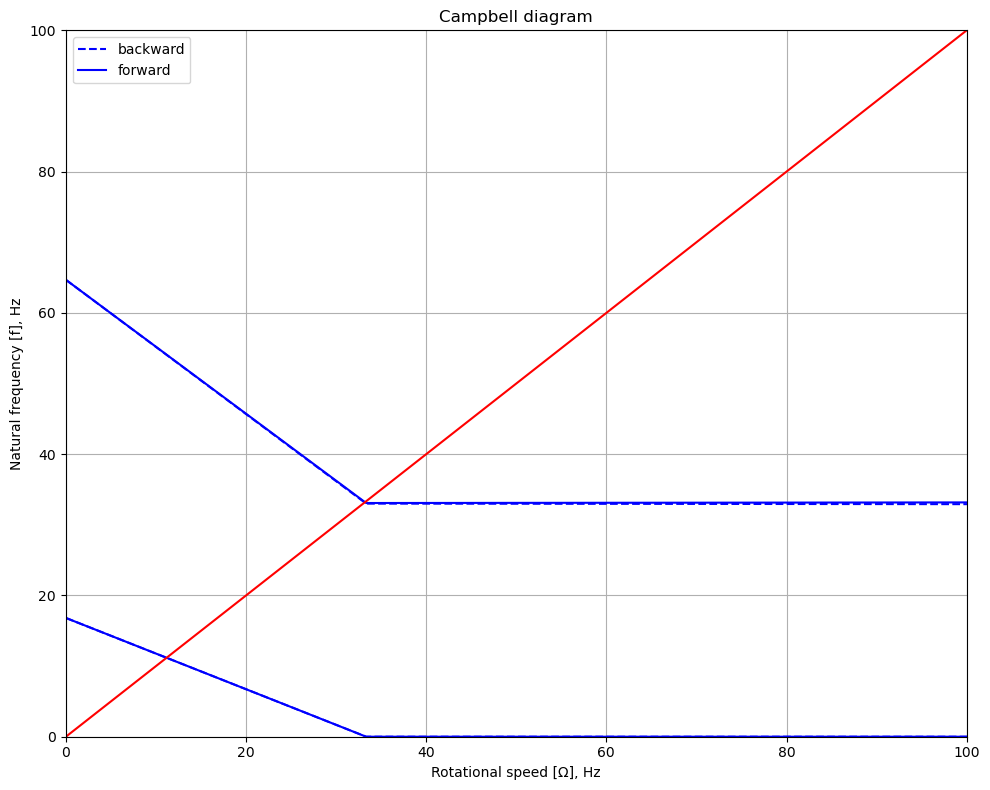

LeigOmega shape: (88, 11)
CAMP shape: (88, 11)
Number of speeds: 11
X points: 12

Собственные частоты при Ω=0 (первые 2):
  f_n[0] = 16.813702594875224 Hz
  f_n[1] = 16.813702595459766 Hz
  f_n[2] = 64.68011626927554 Hz
  f_n[3] = 64.68011626933487 Hz
              0             1             2             3             4   \
0   1.168812e-27  9.676892e-27  1.564851e-25  1.518011e-11  4.640832e-28   
1   1.298047e-26  2.132300e-24  2.789475e-24  1.518011e-11  1.841795e-25   
2   1.209819e-12  1.833409e-20  1.067796e-10  1.334491e-05  5.876710e-07   
3   1.209887e-12  1.978972e-20  1.067802e-10  1.334491e-05  5.879049e-07   
4   7.084294e-06  4.789334e-06  1.474634e-05  1.804152e-05  5.881178e-07   
5   7.084294e-06  4.789334e-06  1.474634e-05  1.804152e-05  5.883517e-07   
6   7.073951e-01  1.400559e+00  2.066742e+00  2.695816e+00  3.280859e+00   
7   7.073951e-01  1.400559e+00  2.066742e+00  2.695816e+00  3.280859e+00   
8   1.626455e+01  1.581591e+01  1.540519e+01  1.503152e+01  1.46

In [45]:
##### ДИАГРАММА КЭМПБЕЛЛА #####

# =============================================================================
# ФУНКЦИЯ POLYEIG
# =============================================================================
def polyeig(*A):
    n = A[0].shape[0]
    k = len(A) - 1
    
    M = np.zeros((n*k, n*k), dtype=np.complex128)
    
    for i in range(n*(k-1)):
        M[i, i+n] = 1.0
    
    for i in range(k):
        M[(k-1)*n:, i*n:(i+1)*n] = -A[i]
    
    eigenvalues, eigenvectors = eig(M)
    mask = np.isfinite(eigenvalues)
    eigenvalues = eigenvalues[mask]
    eigenvectors = eigenvectors[:n, mask]
    
    return eigenvalues, eigenvectors

# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================
Omegastart = 2000    # RPM
Omegafinal = 22000   # RPM
Omegastep = 2000     # RPM

Omega_rad = np.arange((Omegastart * 2 * np.pi) / 60, 
                      ((Omegafinal + Omegastep) * 2 * np.pi) / 60, 
                      (Omegastep * 2 * np.pi) / 60)

n_speeds = len(Omega_rad)


# n_rows = 2 * len(f_n)  # т.к. прямая и обратная
# n_cols = int(Omegafinal / Omegastep)  # Omegafinal/Omegastep = 22000/2000 = 11

# # Формирование матрицы LеigOmegа: строки - исходное решение задачи на собственные значения, столбцы - частота возбуждения, [рад/с]
# LeigOmega = np.zeros((n_rows, n_cols), dtype=complex)
# j_omega = 0

# for Omega in Omega_rad:
#     # Leig = polyeig(K, Omega*G, M)
#     Leig, _ = polyeig(K, Omega * G, M)
#     for i in range(len(Leig)):
#         if i < n_rows:  # чтобы не выйти за границы
#             LeigOmega[i, j_omega] = Leig[i]
    
#     j_omega += 1 

# # =============================================================================
# # ФОРМИРОВАНИЕ МАТРИЦЫ CAMP - строки - собственные частоты, [Гц], столбцы - частоты возбуждения, [рад/с]
# # =============================================================================

# CAMP = np.zeros((n_rows, j_omega))

# for i in range(j_omega): 
#     for j in range(n_rows):
#         CAMP[j, i] = np.imag(LeigOmega[j, i]) / (2 * np.pi)
        
# for i in range(j_omega):
#     CAMP[:, i] = np.sort(np.abs(CAMP[:, i]))
##################################################################################
# === Исправление размеров и источников частот ===
# f_n не определена здесь — используем freqs, полученные ранее:
# (если вы предпочитаете другое имя, можно сделать f_n = freqs перед этим блоком)
f_n = freqs  # freqs возвращается из solve_eigen_and_plot(...)

n_rows = 2 * len(f_n)      # двойной набор: forward + backward
n_cols = n_speeds          # число исследуемых скоростей = len(Omega_rad)

# Инициализация массива для хранения корней при каждой скорости
LeigOmega = np.zeros((n_rows, n_cols), dtype=complex)

j_omega = 0
for Omega in Omega_rad:
    # используем G0 (базовую гироскопическую матрицу без масштабирования)
    # и умножаем на текущую Omega внутри цикла:
    Leig, _ = polyeig(K, Omega * G0, M)
    # записываем найденные корни в столбец j_omega
    for i_leig in range(min(len(Leig), n_rows)):
        LeigOmega[i_leig, j_omega] = Leig[i_leig]
    j_omega += 1  # обязательно инкрементируем индекс столбца

# Формирование CAMP (строки - моды, столбцы - скорости), частоты в Гц
CAMP = np.zeros((n_rows, n_cols))
for j in range(n_cols):
    CAMP[:, j] = np.imag(LeigOmega[:, j]) / (2.0 * np.pi)
    CAMP[:, j] = np.sort(np.abs(CAMP[:, j]))

##################################################################################



# =============================================================================
# ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА 
# =============================================================================
plt.figure(figsize=(10, 8))

X = np.arange(0, Omegafinal/60 + Omegastep/60, Omegastep/60)

# Первые две моды
k = 0  
m = 2  
for i in range(0, 3, 2):  # i = 0, 2
    # Берем первую 
    q = 0
    for j in range(k, m+1, 2):
        f1 = np.zeros(12)
        f1[0] = f_n[i] 
        for idx in range(1, 12):
            if idx-1 < CAMP.shape[1]:  # проверяем границы
                f1[idx] = CAMP[j, idx-1]
        # Прямая или обратная
        if q == 0:
            plt.plot(X[:len(f1)], f1[:len(X)], 'b--', linewidth=1.5)
        else:
            plt.plot(X[:len(f1)], f1[:len(X)], 'b-', linewidth=1.5)
        q = 1
    # Берем вторую
    k += 12
    m += 12

# Диагональ
X_line = np.arange(0, Omegafinal/60 + 50, 50)
f2 = X_line
plt.plot(X_line, f2, 'r-', linewidth=1.5)

plt.xlim([0, 100])
plt.ylim([0, 100])

plt.grid(True)
plt.legend(['backward', 'forward'], loc='upper left')
plt.title('Campbell diagram')
plt.xlabel('Rotational speed [Ω], Hz')
plt.ylabel('Natural frequency [f], Hz')

plt.tight_layout()
plt.show()

# =============================================================================
# ВЫВОД ИНФО
# =============================================================================
print(f"LeigOmega shape: {LeigOmega.shape}")
print(f"CAMP shape: {CAMP.shape}")
print(f"Number of speeds: {n_speeds}")
print(f"X points: {len(X)}")

print(f"\nСобственные частоты при Ω=0 (первые 2):")
for i in range(min(4, len(f_n))):
    print(f"  f_n[{i}] = {f_n[i]:} Hz")

print(pd.DataFrame(CAMP).head(20))